In [27]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [28]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'is_gesture'

In [29]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
session_task_min_max_marker AS (
    SELECT
        session_task_id,
        MIN(sensor_data_index) AS min_index,
        MAX(sensor_data_index) AS max_index
    FROM preciseMarker
    GROUP BY session_task_id
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        stmm.min_index,
        stmm.max_index,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 'no' ELSE 'yes' END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    LEFT JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    LEFT JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN session_task_min_max_marker stmm
      ON stmm.session_task_id = sd.session_task_id
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title NOT IN ('Szenarien', 'Tap and Hold') AND sd.session_task_row_index BETWEEN stmm.min_index AND stmm.max_index
)
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [30]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")
df_raw["is_gesture"] = df_raw["is_gesture"].astype("category")

In [31]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [32]:
is_null = df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
df_raw["group_id"] = df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [33]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'pressure' in col:
#         df_raw[col] = df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 3. Normalize channel values using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'channel' in col:
#         df_raw[col] = df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 4. Normalize motor_angle using min max scaling to [0, 1], per participant
# df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
#     lambda x: (x - x.min()) / (x.max() - x.min())
# )       

In [34]:
df_raw[LABEL_COLUMN].value_counts()

is_gesture
no     205245
yes     40725
Name: count, dtype: int64

In [35]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    30680
6331fbd1-76bb-48d6-92a2-80a55a70d134    27969
696b4743-9d39-4fb1-8271-90e7d48652af    18586
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    37826
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    29543
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    36132
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    32275
fdd02af8-c764-43ba-8247-c612f85568b4    32959
dtype: int64

In [36]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [37]:
TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [38]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


In [39]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean.isna().sum()

id                        0
min_index                 0
max_index                 0
session_task_id           0
session_task_row_index    0
row_index                 0
timestamp                 0
timestamp_ms              0
button_pressed            0
motor_angle               0
gesture                   0
parent_gesture            0
participant_id            0
is_gesture                0
group_id                  0
estimated_timestamp       0
touch_1_position          0
touch_1_pressure          0
touch_1_channel           0
touch_2_position          0
touch_2_pressure          0
touch_2_channel           0
touch_3_position          0
touch_3_pressure          0
touch_3_channel           0
touch_4_position          0
touch_4_pressure          0
touch_4_channel           0
touch_5_position          0
touch_5_pressure          0
touch_5_channel           0
active_ids                0
dtype: int64

In [40]:
# Create sliding windows from the cleaned DataFrame
X_windows = []
y_windows = []
meta_data = []

WINDOW_SIZE = 200
WINDOW_STRIDE = 20

print("Creating sliding windows...")
for (session_task_id, participant_id), group in df_clean.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group[LABEL_COLUMN].values

    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE + 1, WINDOW_STRIDE):
        end = start + WINDOW_SIZE
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]

        real_label = "no"
        if "yes" in window_labels and window_labels[0] == 'no' and window_labels[-1] == "no":
            real_label = "yes"
        
        X_windows.append(window_data)
        y_windows.append(real_label)
        meta_data.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end,
        })
X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
meta_data_df = pd.DataFrame(meta_data)
print(f"Created {X_windows.shape[0]} windows of size {WINDOW_SIZE} samples.")
# Display the shape of the created windows
X_windows.shape, y_windows.shape, meta_data_df.shape

Creating sliding windows...
Created 10483 windows of size 200 samples.


((10483, 200, 17), (10483,), (10483, 4))

In [41]:
# Print the value counts of the labels in the windows
unique, counts = np.unique(y_windows, return_counts=True)
label_counts = dict(zip(unique, counts))
print("Window Label Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Window Label Counts:
no: 6609
yes: 3874


In [42]:
def extract_features(window, is_padded_window, TOUCH_MOVE_THRESHOLD=0.01):
    # 1. SETUP & INITIALIZATION
    features = []
    feature_names = []
    
    # Indices based on your sensor layout
    button_col = 0
    motor_angle_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]
    touch_pressure_cols = [3, 6, 9, 12, 15]
    touch_position_cols = [2, 5, 8, 11, 14]
    original_length_col = window.shape[1] - 1 # Assuming it's the last column
    
    # Required for the continuous touch logic
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    def circular_range(angles):
        if len(angles) == 0: return 0
        sorted_angles = np.sort(angles)
        gaps = np.diff(sorted_angles)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        all_gaps = np.append(gaps, wrap_gap)
        return 2 * np.pi - np.max(all_gaps)

    # 2. PRE-PROCESSING: Zero out inactive fingers
    # We work on a copy to avoid mutating the original window if it's used elsewhere
    working_window = window.copy()
    
    for i in range(len(touch_position_cols)):
        pos_idx = touch_position_cols[i]
        press_idx = touch_pressure_cols[i]
        chan_idx = touch_channel_cols[i]
        
        f_pressures = working_window[:, press_idx]
        f_positions = np.nan_to_num(working_window[:, pos_idx], nan=0.0)
        
        is_touching = f_pressures > 0
        
        if np.any(is_touching):
            # Calculate movement
            valid_positions = f_positions[is_touching]
            c_range = circular_range(valid_positions)
            has_moved = c_range > TOUCH_MOVE_THRESHOLD
            
            # Calculate continuity
            start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
            end_of_touches = is_touching & ~np.append(is_touching[1:], False)
            touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
            min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
            is_continuous_touch = min_touch_duration >= original_length - 1
            
            # THE LOGIC: If not active/moving, zero out the finger data
            is_active = (has_moved or not is_continuous_touch)
            if not is_active:
                working_window[:, [pos_idx, press_idx, chan_idx]] = 0
        else:
            # If never touching, ensure it's 0
            working_window[:, [pos_idx, press_idx, chan_idx]] = 0

    # 3. FEATURE EXTRACTION (Now using working_window)
    touch_pressures = working_window[:, touch_pressure_cols]
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)
    
    # Button Features
    button_data = window[:, button_col]
    add_feature("button_was_pressed", 1 if np.any(button_data > 0) else 0)
    add_feature("button_mean", np.mean(button_data))
    add_feature("button_std", np.std(button_data))
    add_feature("button_max", np.max(button_data))
    add_feature("button_min", np.min(button_data))
    add_feature("button_range", np.max(button_data) - np.min(button_data))
    add_feature("button_q25", np.percentile(button_data, 25))
    add_feature("button_q75", np.percentile(button_data, 75))

    # Motor Angle Features
    motor_data = window[:, motor_angle_col]
    add_feature("motor_angle_mean", np.mean(motor_data))
    add_feature("motor_angle_std", np.std(motor_data))
    add_feature("motor_angle_max", np.max(motor_data))
    add_feature("motor_angle_min", np.min(motor_data))
    add_feature("motor_angle_range", np.max(motor_data) - np.min(motor_data))
    add_feature("motor_angle_q25", np.percentile(motor_data, 25))
    add_feature("motor_angle_q75", np.percentile(motor_data, 75))

    # General Touch Activity Features
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    add_feature("any_touch", np.any(active_touches))
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    add_feature("max_pressure", np.max(touch_pressures))
    
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)

    # --- Distances between fingers (using filtered working_window) ---
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    dist_idx = 0
    for p1_idx, p2_idx in combinations(range(5), 2):
        dist_idx += 1
        f1_pos = working_window[:, touch_position_cols[p1_idx]]
        f2_pos = working_window[:, touch_position_cols[p2_idx]]
        f1_press = working_window[:, touch_pressure_cols[p1_idx]]
        f2_press = working_window[:, touch_pressure_cols[p2_idx]]
        
        valid_dist_mask = (f1_press > 0) & (f2_press > 0)
        distances = short_dist(f1_pos[valid_dist_mask], f2_pos[valid_dist_mask])

        # Split the distances in 5 equal bins and get the distance values per bin for better time perception
        distance_parts = np.array_split(distances, 5)
        for bin_idx, part in enumerate(distance_parts):
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_mean", np.mean(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_max", np.max(part) if len(part) > 0 else 0)
            add_feature(f"finger_distance_{dist_idx}_bin_{bin_idx+1}_min", np.min(part) if len(part) > 0 else 0)

        has_distance = len(distances) != 0
        add_feature(f"finger_distance_{dist_idx}_mean", np.mean(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_max", np.max(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_min", np.min(distances) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q25", np.percentile(distances, 25) if has_distance else 0)
        add_feature(f"finger_distance_{dist_idx}_q75", np.percentile(distances, 75) if has_distance else 0)

    # --- Per Finger Features ---
    amount_active_moving_fingers = 0
    for i in range(len(touch_position_cols)):
        finger_positions = working_window[:, touch_position_cols[i]]
        finger_pressures = working_window[:, touch_pressure_cols[i]]
        finger_channels = working_window[:, touch_channel_cols[i]]

        is_touching = finger_pressures > 0
        # Re-calculating these for the specific finger features
        circle_range = circular_range(finger_positions[is_touching]) if np.any(is_touching) else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        
        # Continuity check for the count
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_durations = np.where(end_of_touches)[0] - np.where(start_of_touches)[0]
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        is_continuous_touch = min_touch_duration >= original_length - 1

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)

    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [43]:
le = LabelEncoder()
y_windows_encoded = le.fit_transform(y_windows)

In [44]:
feature_names = extract_features(X_windows[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_windows_extracted = np.array([extract_features(win, False)[0] for win in X_windows], dtype=np.float32)
print(f"Extracted features shape: {X_windows_extracted.shape}")  # should be (N_windows, N_features)

Extracted features shape: (10483, 398)


In [45]:
# Print nan for both datasets after feature extraction
print(f"NaN in windows after feature extraction: {np.isnan(X_windows_extracted).any()}")

NaN in windows after feature extraction: False


In [46]:
# Set all nan values to 0
X_win = np.nan_to_num(X_windows_extracted, nan=0.0)

In [47]:
participant_ids = meta_data_df['participant_id'].unique().tolist()
amount_of_participants = len(participant_ids)

train_pids = participant_ids[:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

print(f"Amount of participants: {amount_of_participants} (Train: {len(train_pids)}, Test: {len(test_pids)})")

Amount of participants: 8 (Train: 7, Test: 1)


In [48]:
# Split sliding windows
train_mask_win = meta_data_df['participant_id'].isin(train_pids)
X_train_win = X_win[train_mask_win]
y_train_win = y_windows_encoded[train_mask_win]

test_mask_win = meta_data_df['participant_id'].isin(test_pids)
X_test_win = X_win[test_mask_win]
y_test_win = y_windows_encoded[test_mask_win]

In [49]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train_win == label_int)
    test_count = np.sum(y_test_win == label_int)
    print(f"Label: {label} | Train: {train_count} | Test: {test_count}")

Label: no | Train: 5646 | Test: 963
Label: yes | Train: 3257 | Test: 617


In [50]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Sliding Window Split:")
print(f"  X_train_win: {X_train_win.shape}, y_train_win: {y_train_win.shape}")
print(f"  X_test_win:  {X_test_win.shape},  y_test_win:  {y_test_win.shape}")

Sliding Window Split:
  X_train_win: (8903, 398), y_train_win: (8903,)
  X_test_win:  (1580, 398),  y_test_win:  (1580,)


In [51]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform, loguniform

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(200, 1000),
            "clf__max_depth":         [None, 8, 12, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },
    {
        "name": "GradientBoosting",
        "pipeline": Pipeline([
            ("clf", GradientBoostingClassifier(
                random_state=42
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":   randint(100, 600),
            "clf__learning_rate":  loguniform(1e-2, 2e-1),
            "clf__max_depth":      randint(2, 6),
            "clf__subsample":      uniform(0.6, 0.4),   # 0.6–1.0
        },
    },
    {
        "name": "LogisticRegression",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                multi_class="multinomial",
                n_jobs=-1,
                solver="lbfgs"
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
            ],
        },
    },
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "clf__n_estimators":      randint(300, 1200),
            "clf__max_depth":         [None, 8, 12, 20, 30],
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf":  randint(1, 10),
            "clf__max_features":      ["sqrt", "log2", 0.3, 0.5],
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },
    {
        "name": "LinearSVC",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                max_iter=5000,
                dual=False
            ))
        ]),
        "param_grid": {
            "clf__C":            loguniform(1e-3, 1e2),
            "clf__class_weight":      [
                None, 
                "balanced",
                {0: 1, 1: 5},
                {0: 1, 1: 10},
                {0: 1, 1: 20},
                {0: 1, 1: 40},
            ],
        },
    },
    {
        "name": "AdaBoost",
        "pipeline": Pipeline([
            ("clf", AdaBoostClassifier(
                random_state=42
            ))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(100, 600),
            "clf__learning_rate": loguniform(1e-2, 1.0),
        },
    }
]

In [52]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
)
import numpy as np
import pandas as pd

# SCORING = make_scorer(recall_score, pos_label=yes_label_int, average="macro")
SCORERS = {
    "recall": make_scorer(recall_score, average="macro"),
    "precision": make_scorer(precision_score, average="macro", zero_division=0),
    "f1": make_scorer(f1_score, average="macro"),
}

OPTIMIZE_METRIC = "recall"

gkf = GroupKFold(n_splits=amount_of_participants - 1)
groups_train = meta_data_df[train_mask_win]['participant_id'].values

best_model = None
best_model_name = None
best_score = -np.inf

rows = []
for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]

    print(f"\n=== Tuning {name} ===")

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["param_grid"],
        n_iter=40,
        cv=gkf,
        scoring=SCORERS,
        refit=OPTIMIZE_METRIC,
        return_train_score=True,
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    search.fit(X_train_win, y_train_win, groups=groups_train)

    idx = search.best_index_
    cv = search.cv_results_

    print(f"Best CV {OPTIMIZE_METRIC} Score: {cv[f'mean_test_{OPTIMIZE_METRIC}'][idx]:.4f}")

    # -----------------------------
    # Track best overall model
    # -----------------------------
    if cv[f"mean_test_{OPTIMIZE_METRIC}"][idx] > best_score:
        print("--> New Best Model Found!")
        best_score = cv[f"mean_test_{OPTIMIZE_METRIC}"][idx]
        best_model = search.best_estimator_
        best_model_name = name

    # -----------------------------
    # Store CV stats
    # -----------------------------
    row = {
        "model": name,
        "cv_recall": cv["mean_test_recall"][idx],
        "cv_recall_std": cv["std_test_recall"][idx],
        "cv_precision": cv["mean_test_precision"][idx],
        "cv_precision_std": cv["std_test_precision"][idx],
        "cv_f1": cv["mean_test_f1"][idx],
        "cv_f1_std": cv["std_test_f1"][idx],
        "train_recall_cv": cv["mean_train_recall"][idx],
        "train_precision_cv": cv["mean_train_precision"][idx],
        "train_f1_cv": cv["mean_train_f1"][idx],
        'best_model': search.best_estimator_,
        **search.best_params_,
    }

    rows.append(row)

# Print the best model stats
print(f"\n=== Best Model: {best_model_name} ===")
print(f"Best CV {OPTIMIZE_METRIC}: {best_score:.4f}")


=== Tuning RandomForest ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV recall Score: 0.7798
--> New Best Model Found!

=== Tuning GradientBoosting ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV recall Score: 0.7548

=== Tuning LogisticRegression ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV recall Score: 0.7780

=== Tuning ExtraTrees ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV recall Score: 0.7968
--> New Best Model Found!

=== Tuning LinearSVC ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV recall Score: 0.7801

=== Tuning AdaBoost ===
Fitting 7 folds for each of 40 candidates, totalling 280 fits
Best CV recall Score: 0.7534

=== Best Model: ExtraTrees ===
Best CV recall: 0.7968


In [115]:
from sklearn.metrics import recall_score, precision_score, f1_score

def eval_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        "recall": recall_score(y, y_pred, average="macro"),
        "precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y, y_pred, average="macro"),
    }


In [116]:
for row in rows:
    if row['model'] == 'KNN' or row['model'] == 'RadiusNeighbors': # KNN Takes too long to evaluate on test set
        continue
    print(f"Evaluating model {row['model']} on test set...")
    model = row['best_model']
    test_stats = eval_metrics(model, X_test_win, y_test_win)
    for k, v in test_stats.items():
        row[f"test_{k}"] = v

Evaluating model RandomForest on test set...
Evaluating model GradientBoosting on test set...
Evaluating model LogisticRegression on test set...
Evaluating model ExtraTrees on test set...
Evaluating model LinearSVC on test set...
Evaluating model AdaBoost on test set...


In [117]:
df = pd.DataFrame(rows).sort_values(
    "cv_recall", ascending=False
).reset_index(drop=True)

df["cv_recall_fmt"] = (
    df["cv_recall"].map("{:.3f}".format)
    + " ± "
    + df["cv_recall_std"].map("{:.3f}".format)
)

df["cv_precision_fmt"] = (
    df["cv_precision"].map("{:.3f}".format)
    + " ± "
    + df["cv_precision_std"].map("{:.3f}".format)
)

df["cv_f1_fmt"] = (
    df["cv_f1"].map("{:.3f}".format)
    + " ± "
    + df["cv_f1_std"].map("{:.3f}".format)
)

display_cols = [
    "model",
    "cv_recall",
    "cv_precision",
    "cv_f1",
    "test_recall",
    "test_precision",
    "test_f1",
]

print("\n=== Model Comparison ===")
print(df[display_cols].to_string(index=False))

print(f"\nBest overall model: {best_model_name}")
print(best_model)


=== Model Comparison ===
             model  cv_recall  cv_precision    cv_f1  test_recall  test_precision  test_f1
        ExtraTrees   0.796799      0.788130 0.781500     0.866644        0.850889 0.853865
         LinearSVC   0.780077      0.765088 0.756461     0.785133        0.771470 0.769223
      RandomForest   0.779801      0.771946 0.765273     0.821555        0.812300 0.815560
LogisticRegression   0.778036      0.763249 0.756621     0.794313        0.780301 0.779152
  GradientBoosting   0.754768      0.765052 0.752224     0.763237        0.782388 0.769639
          AdaBoost   0.753414      0.750988 0.745736     0.731589        0.732698 0.732123

Best overall model: ExtraTrees
Pipeline(steps=[('clf',
                 ExtraTreesClassifier(class_weight={0: 1, 1: 10}, max_depth=30,
                                      max_features=0.3, min_samples_leaf=8,
                                      min_samples_split=8, n_estimators=421,
                                      n_jobs=-1,

Test classification report:
               precision    recall  f1-score   support

          no       0.94      0.82      0.88       963
         yes       0.77      0.91      0.83       617

    accuracy                           0.86      1580
   macro avg       0.85      0.87      0.85      1580
weighted avg       0.87      0.86      0.86      1580



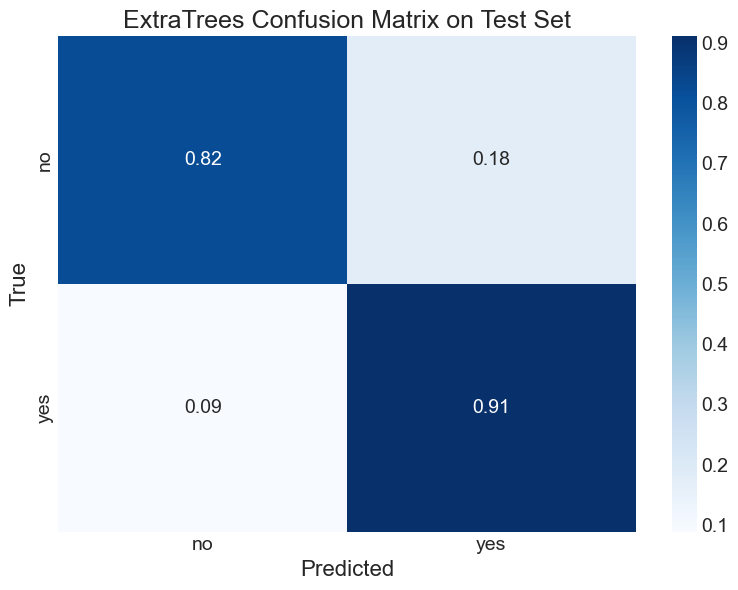

In [118]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test_win)

print("Test classification report:\n",
      classification_report(y_test_win, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_win, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues", 
            annot_kws={"fontsize": 14})
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
plt.title(f"{best_model_name} Confusion Matrix on Test Set", fontsize=18)
plt.tight_layout()
plt.show()

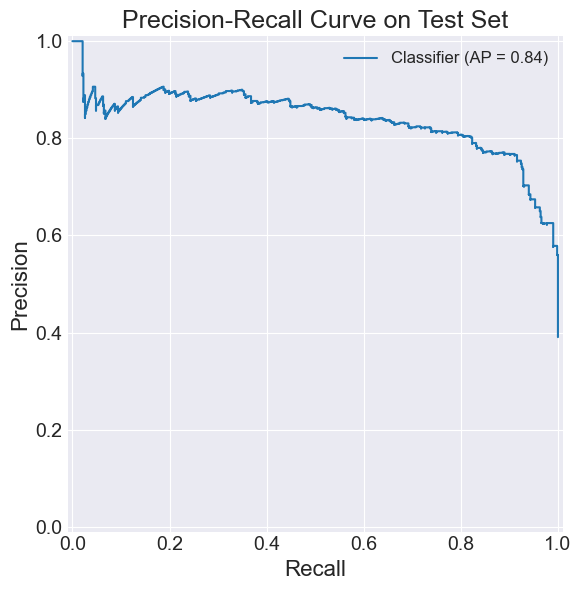

In [109]:
# draw a precision recall curve for the best model
from sklearn.metrics import PrecisionRecallDisplay
y_test_pred_probs = best_model.predict_proba(X_test_win)[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
disp = PrecisionRecallDisplay.from_predictions(
    y_test_win,
    y_test_pred_probs,
    ax=ax
)

disp.ax_.set_xlabel("Recall", fontsize=16)                  # x-axis
disp.ax_.set_ylabel("Precision", fontsize=16)              # y-axis
disp.ax_.tick_params(axis='both', labelsize=12)            # tick labels
disp .ax_.legend(fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Precision-Recall Curve on Test Set', fontsize=18)
plt.tight_layout()
plt.show()


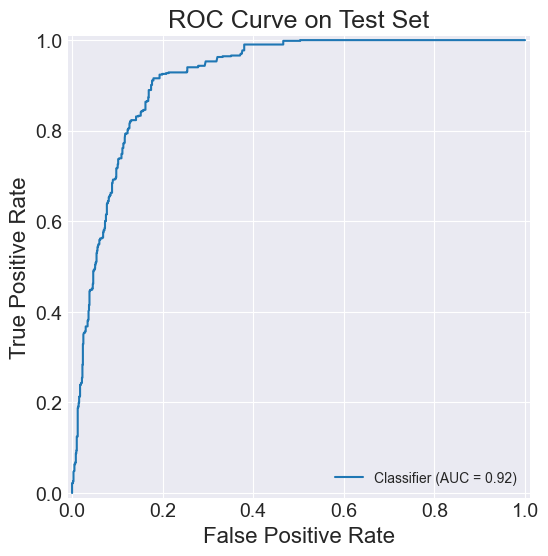

In [110]:
# draw a receiver operating characteristic (ROC) curve for the best model
from sklearn.metrics import RocCurveDisplay
y_test_pred_probs = best_model.predict_proba(X_test_win)[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
roc_display = RocCurveDisplay.from_predictions(
    y_test_win,
    y_test_pred_probs,
    ax=ax
)

roc_display.ax_.set_xlabel("False Positive Rate", fontsize=16)   # x-axis
roc_display.ax_.set_ylabel("True Positive Rate", fontsize=16)    # y-axis
roc_display.ax_.tick_params(axis='both', labelsize=12)          # tick labels
disp .ax_.legend(fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("ROC Curve on Test Set", fontsize=18)
plt.show()

## Test with Szenario

In [67]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    rt.title AS gesture,
    rtParent.title AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'Tap and Hold' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'Tap and Hold' THEN 'no' ELSE 'yes' END AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE rtParent.title = 'Szenarien'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None


In [68]:
# Print counts of unique gestures per participant_id
counts = (
    szenarien_df_raw
    .groupby(['participant_id', 'gesture'])
    .size()
    .reset_index(name='count')
)

print(counts)

                          participant_id           gesture  count
0   6331fbd1-76bb-48d6-92a2-80a55a70d134   Bild vergrößern   1389
1   6331fbd1-76bb-48d6-92a2-80a55a70d134  Dateien kopieren   2099
2   6331fbd1-76bb-48d6-92a2-80a55a70d134    Musik Vorschau   1374
3   696b4743-9d39-4fb1-8271-90e7d48652af   Bild vergrößern   1013
4   696b4743-9d39-4fb1-8271-90e7d48652af  Dateien kopieren   1029
5   696b4743-9d39-4fb1-8271-90e7d48652af    Musik Vorschau    928
6   6a1b56e6-47ce-43cb-96cb-713d055d8f6d   Bild vergrößern   2817
7   6a1b56e6-47ce-43cb-96cb-713d055d8f6d  Dateien kopieren   2009
8   6a1b56e6-47ce-43cb-96cb-713d055d8f6d    Musik Vorschau   2355
9   707c3867-fe15-4b05-bf7b-fc5f3b501fb1   Bild vergrößern   1425
10  707c3867-fe15-4b05-bf7b-fc5f3b501fb1    Musik Vorschau   1195
11  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0   Bild vergrößern    913
12  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0  Dateien kopieren   1204
13  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    Musik Vorschau   2362
14  d3b39f

In [69]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [70]:
is_null = szenarien_df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
szenarien_df_raw["group_id"] = szenarien_df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [71]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df_raw[col] = szenarien_df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'pressure' in col:
#         szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 3. Normalize channel values using min max scaling to [0, 1], per participant
# for col in SENSOR_COLUMNS:
#     if 'channel' in col:
#         szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
#             lambda x: (x - x.min()) / (x.max() - x.min())
#         )
# # 4. Normalize motor_angle using min max scaling to [0, 1], per participant
# szenarien_df_raw['motor_angle'] = szenarien_df_raw.groupby('participant_id')['motor_angle'].transform(
#     lambda x: (x - x.min()) / (x.max() - x.min())
# )       

In [72]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [73]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df.isna().sum()

id                        0
session_task_id           0
session_task_row_index    0
timestamp                 0
button_pressed            0
motor_angle               0
gesture                   0
parent_gesture            0
participant_id            0
is_gesture                0
marker_label              0
group_id                  0
estimated_timestamp       0
timestamp_ms              0
touch_1_position          0
touch_1_pressure          0
touch_1_channel           0
touch_2_position          0
touch_2_pressure          0
touch_2_channel           0
touch_3_position          0
touch_3_pressure          0
touch_3_channel           0
touch_4_position          0
touch_4_pressure          0
touch_4_channel           0
touch_5_position          0
touch_5_pressure          0
touch_5_channel           0
active_ids                0
dtype: int64

In [74]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
no     27560
yes     6248
Name: count, dtype: int64


In [76]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)
streams_meta = {}

for sid, sdf in szenarien_df.groupby("session_task_id"):
    X_stream = sdf[SENSOR_COLUMNS].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    meta_stream = {
        "participant_id": sdf["participant_id"].iloc[0],
        "session_task_id": sid,
        "num_samples": len(sdf),
    }
    streams[sid] = X_stream
    streams_labels[sid] = y_stream
    streams_meta[sid] = meta_stream

In [77]:
max_len = 200
step_size = 10

print(f"Using max_len={max_len} for online prediction.")
def predict_stream_online(X_stream, y_stream):
    T, D = X_stream.shape
    preds = []
    probas = []
    real_labels = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        window_raw = X_stream[t_start:t_end]
        window = extract_features(window_raw, False)[0]
        window_labels = y_stream[t_start:t_end]

        real_label = 'no'
        if 'yes' in window_labels and window_labels[0] == 'no' and window_labels[-1] == 'no':
            real_label = 'yes'
        real_labels.append(real_label)

        window = np.nan_to_num(window, nan=0.0).reshape(1, -1)
        proba = best_model.predict_proba(window)[0]
        probas.append(proba)

        cls_idx = np.argmax(proba)
        label = le.classes_[cls_idx]
        preds.append(label)

    return np.array(preds), np.array(real_labels), np.array(probas), windows


Using max_len=200 for online prediction.


In [78]:
all_true = []
all_prediced = []
all_probabilities = []

total_streams = len(streams)
current_stream = 1
for sid, X_stream in streams.items():
    print(f"Predicting stream {current_stream}/{total_streams} (session_task_id={sid})...")
    current_stream += 1
    y_stream = streams_labels[sid]
    preds, real_labels, probas, windows = predict_stream_online(X_stream, y_stream)
    
    all_true.extend(real_labels)
    all_prediced.extend(preds)
    all_probabilities.extend(probas)

Predicting stream 1/20 (session_task_id=002f4422-1f7b-4859-8f03-467e1f752000)...
Predicting stream 2/20 (session_task_id=0542a515-ad14-49ec-84d7-c3b4e8b6ffe2)...
Predicting stream 3/20 (session_task_id=1428d33a-3bff-4f49-ba25-dca7d3980421)...
Predicting stream 4/20 (session_task_id=19bae408-9256-4cb3-930b-4beaa4875157)...
Predicting stream 5/20 (session_task_id=2789503c-76bf-4451-9bf7-9b7417c8b08e)...
Predicting stream 6/20 (session_task_id=319a52f3-2f36-4460-ba9d-a4346666683f)...
Predicting stream 7/20 (session_task_id=37f425a5-7c3c-4444-9bca-26e3fd5f0186)...
Predicting stream 8/20 (session_task_id=3be34428-0cf8-44c9-8b61-8172643e235d)...
Predicting stream 9/20 (session_task_id=4828a4ce-5192-4853-906e-1d79fd94da44)...
Predicting stream 10/20 (session_task_id=5658dcb6-a957-4027-a893-3b335e8ca212)...
Predicting stream 11/20 (session_task_id=5c21a030-cd27-4e99-b8c0-18f30cfa3fc3)...
Predicting stream 12/20 (session_task_id=6372259a-787d-4b7c-84b7-2eca71318068)...
Predicting stream 13/20 (

In [79]:
all_true_arr = np.array(all_true)
all_prediced_arr = np.array(all_prediced)
all_probabilities_arr = np.array(all_probabilities)

print(f"Unique true labels: {np.unique(all_true_arr)}")
print(f"Unique predicted labels: {np.unique(all_prediced_arr)}")

Unique true labels: ['no' 'yes']
Unique predicted labels: ['no' 'yes']


In [80]:
from sklearn.metrics import confusion_matrix, classification_report

all_true_int = le.transform(all_true_arr)
all_prediced_int = le.transform(all_prediced_arr)

used_labels = np.unique(np.concatenate([all_true_int, all_prediced_int]))
used_labels_names = le.inverse_transform(used_labels)
print(
    classification_report(
        all_true_int,
        all_prediced_int,
        labels=used_labels,
        target_names=used_labels_names
    )
)

              precision    recall  f1-score   support

          no       0.62      0.94      0.75      1834
         yes       0.50      0.10      0.17      1156

    accuracy                           0.61      2990
   macro avg       0.56      0.52      0.46      2990
weighted avg       0.58      0.61      0.52      2990



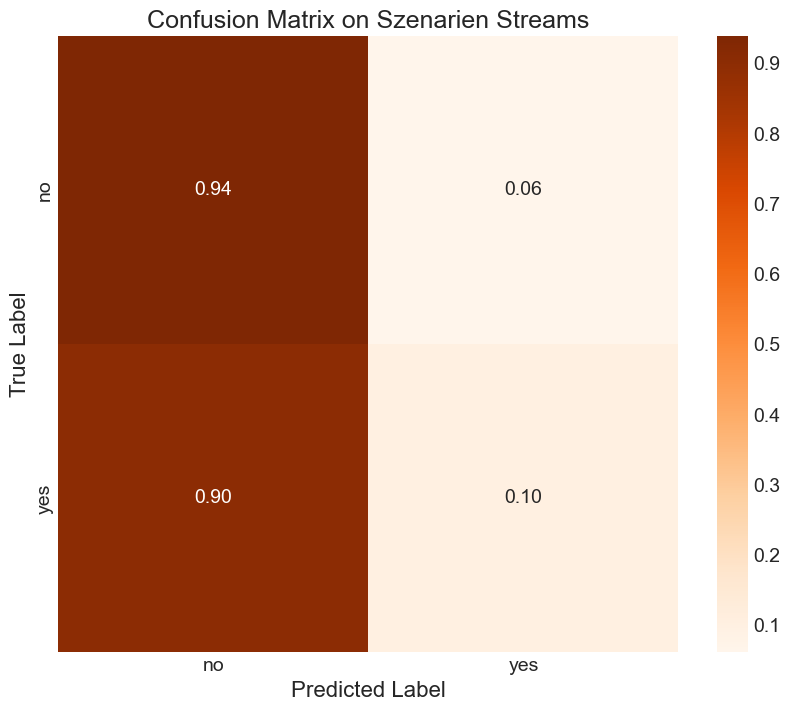

In [111]:
cm = confusion_matrix(all_true_int, all_prediced_int, labels=used_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap="Oranges",
    xticklabels=used_labels_names,
    yticklabels=used_labels_names,
    annot_kws={"fontsize": 14},
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.title('Confusion Matrix on Szenarien Streams', fontsize=18)
plt.show()

## Szenario Full Windows

In [84]:
# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_df.groupby("group_id"):
    X_window = extract_features(gdf[SENSOR_COLUMNS].to_numpy(dtype="float32"), False)[0]
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 319 windows from Szenarien data for group_id prediction.


In [85]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=398, max=398
Window label counts:
  no: 187
  yes: 132


In [86]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_window = np.nan_to_num(X_window, nan=0.0).reshape(1, -1)
    proba = best_model.predict_proba(X_window)[0]
    
    all_window_proba.append(proba)
    all_window_true.append(true_label)

    final_prediction = np.argmax(proba)
    pred_label = le.classes_[final_prediction]
    all_window_pred.append(pred_label)

# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (2) ['no' 'yes']
Unique predicted window labels: (2) ['no' 'yes']


              precision    recall  f1-score   support

          no       0.74      0.95      0.83       187
         yes       0.89      0.53      0.66       132

    accuracy                           0.78       319
   macro avg       0.81      0.74      0.75       319
weighted avg       0.80      0.78      0.76       319



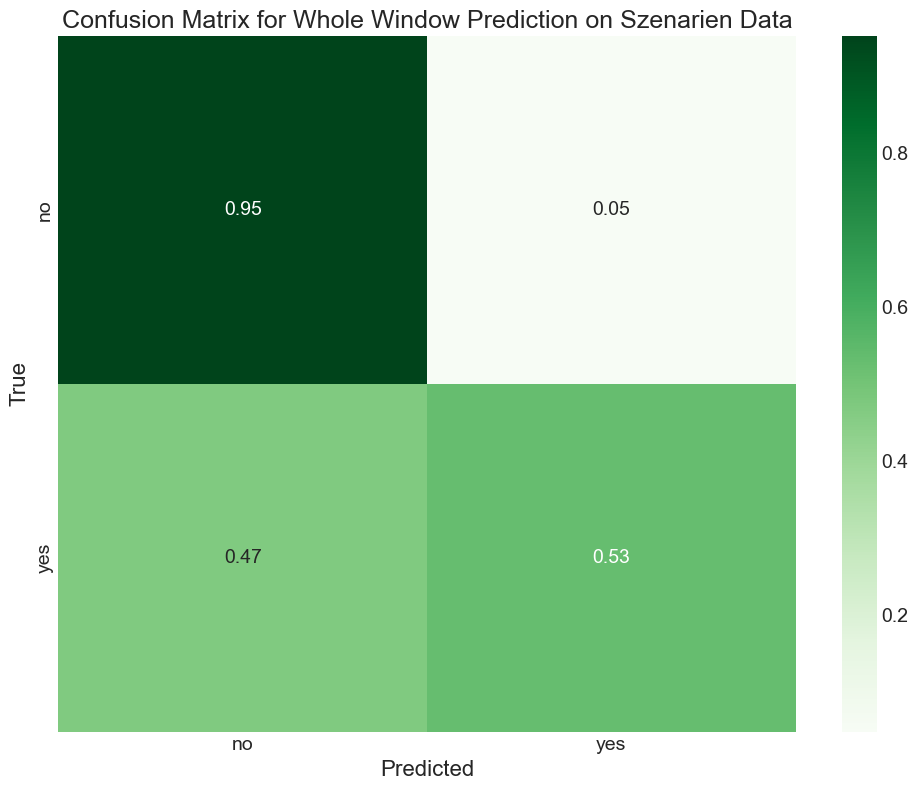

In [114]:
# Print confusion matrix and classification report for window predictions
used_labels_window = np.unique(np.concatenate([all_window_true, all_window_pred]))
print(
    classification_report(
        all_window_true,
        all_window_pred,
        labels=used_labels_window,
    )
)

cm_window = confusion_matrix(all_window_true, all_window_pred)
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=used_labels_window,
    yticklabels=used_labels_window,
    annot_kws={"fontsize": 14}
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data", fontsize=18)
plt.tight_layout()
plt.show()

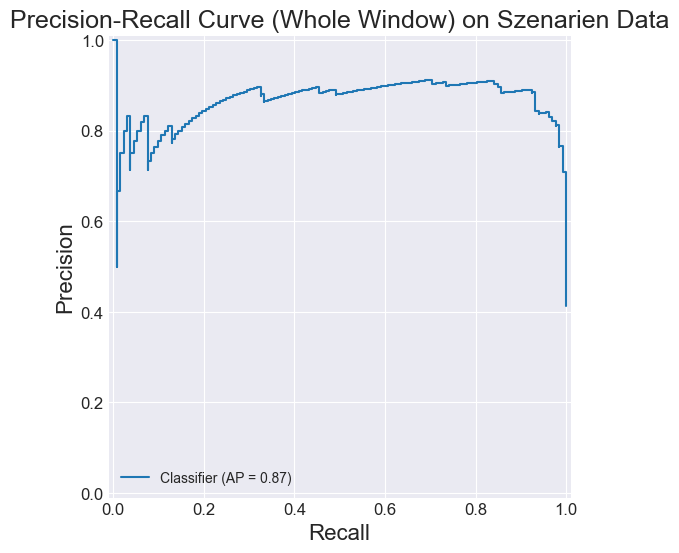

In [88]:
# draw a precision recall curve for the best model
all_window_true_int = le.transform(all_window_true)

fig, ax = plt.subplots(figsize=(10, 6))
PrecisionRecallDisplay.from_predictions(
    all_window_true_int,
    all_window_proba[:, 1],
    ax=ax
)

ax.set_xlabel("Recall", fontsize=16)                  # x-axis
ax.set_ylabel("Precision", fontsize=16)              # y-axis
ax.tick_params(axis='both', labelsize=12)            # tick labels

plt.title('Precision-Recall Curve (Whole Window) on Szenarien Data', fontsize=18)
plt.show()


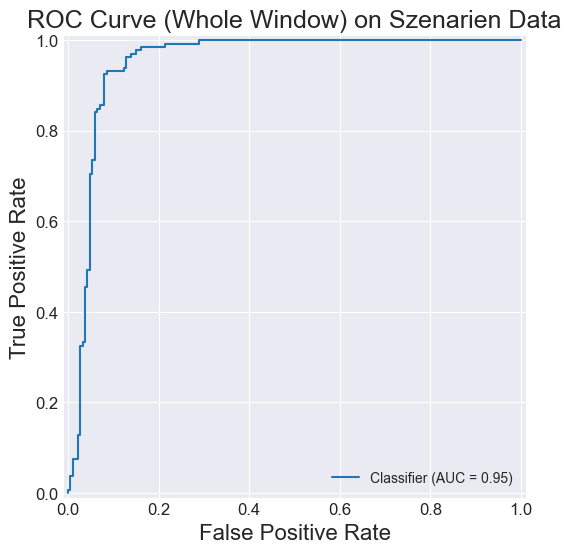

In [89]:
# draw a receiver operating characteristic (ROC) curve for the best model
fig, ax = plt.subplots(figsize=(10, 6))
RocCurveDisplay.from_predictions(
    all_window_true_int,
    all_window_proba[:, 1],
    ax=ax
)

ax.set_xlabel("False Positive Rate", fontsize=16)   # x-axis
ax.set_ylabel("True Positive Rate", fontsize=16)    # y-axis
ax.tick_params(axis='both', labelsize=12)

plt.title("ROC Curve (Whole Window) on Szenarien Data", fontsize=18)
plt.show()